In [1]:
# This code appears in every demonstration Notebook.
# By default, when you run each cell, only the last output of the codes will show.
# This code makes all outputs of a cell show.
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import math
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)

### Data Description

In [4]:
students = pd.read_csv('StudentPerformanceFactors.csv')
students.head()
students.shape
students.info()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


(6607, 20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [5]:
# Examine the unique values of each categorical variable
categorical_columns = ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
                      'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 
                       'Parental_Education_Level', 'Distance_from_Home', 'Gender']

for col in categorical_columns:
    value_counts = students[col].value_counts()
    print('Number of unique values of ' + col + ': ' + str(len(value_counts)))

Number of unique values of Parental_Involvement: 3
Number of unique values of Access_to_Resources: 3
Number of unique values of Extracurricular_Activities: 2
Number of unique values of Motivation_Level: 3
Number of unique values of Internet_Access: 2
Number of unique values of Family_Income: 3
Number of unique values of Teacher_Quality: 3
Number of unique values of School_Type: 2
Number of unique values of Peer_Influence: 3
Number of unique values of Learning_Disabilities: 2
Number of unique values of Parental_Education_Level: 3
Number of unique values of Distance_from_Home: 3
Number of unique values of Gender: 2


Because the number of unique values of each categorical variable is from 2 to 3 values, we don't need to combine the values before getting dummies variables from these categorical columns.

### Data Preparation

#### Handling Missing Values

In [6]:
# Check for missing values
students.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [7]:
# Handle missing values:
# Drop the missing values because the number of missing values is just a few compared to the total number of observations.
students = students.dropna()
students.shape
students.isnull().sum()
# 229 missing values removed

(6378, 20)

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

#### Encoding Categorical Variables

In [8]:
students_transformed = pd.get_dummies(students, columns = categorical_columns, drop_first=True).astype(int)
students_transformed.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,Extracurricular_Activities_Yes,Motivation_Level_Low,Motivation_Level_Medium,Internet_Access_Yes,Family_Income_Low,Family_Income_Medium,Teacher_Quality_Low,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,67,1,0,0,0,0,1,0,1,1,0,0,1,1,0,1,0,1,0,0,1,1
1,19,64,8,59,2,4,61,1,0,0,1,0,1,0,1,0,1,0,1,1,0,0,0,0,0,1,0,0
2,24,98,7,91,2,4,74,0,1,0,1,1,0,1,1,0,1,0,1,1,1,0,0,0,1,0,1,1
3,29,89,8,98,1,4,71,1,0,0,1,1,0,1,1,0,1,0,1,1,0,0,0,1,0,1,0,1
4,19,92,6,65,3,4,70,0,1,0,1,1,0,1,1,0,1,0,0,1,1,0,0,0,0,0,1,0


#### Scaling Numerical Features

In [9]:
numerical_variables = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity',
                          'Exam_Score']
for var in numerical_variables:
    max_value = students[var].max()
    min_value = students[var].min()
    print('Max of ' + var + ' is ' + str(max_value))
    print('Min of ' + var + ' is ' + str(min_value))

Max of Hours_Studied is 44
Min of Hours_Studied is 1
Max of Attendance is 100
Min of Attendance is 60
Max of Sleep_Hours is 10
Min of Sleep_Hours is 4
Max of Previous_Scores is 100
Min of Previous_Scores is 50
Max of Tutoring_Sessions is 8
Min of Tutoring_Sessions is 0
Max of Physical_Activity is 6
Min of Physical_Activity is 0
Max of Exam_Score is 101
Min of Exam_Score is 55


In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
students_transformed_scaled = students_transformed.copy()
students_transformed_scaled[numerical_variables] = scaler.fit_transform(students_transformed[numerical_variables])

In [11]:
students_transformed_scaled.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,Extracurricular_Activities_Yes,Motivation_Level_Low,Motivation_Level_Medium,Internet_Access_Yes,Family_Income_Low,Family_Income_Medium,Teacher_Quality_Low,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,0.505079,0.344520,-0.023819,-0.143491,-1.211858,0.026516,-0.064416,1,0,0,0,0,1,0,1,1,0,0,1,1,0,1,0,1,0,0,1,1
1,-0.163260,-1.387109,0.657418,-1.115763,0.409036,0.998480,-1.597410,1,0,0,1,0,1,0,1,0,1,0,1,1,0,0,0,0,0,1,0,0
2,0.672163,1.556661,-0.023819,1.106573,0.409036,0.998480,1.724077,0,1,0,1,1,0,1,1,0,1,0,1,1,1,0,0,0,1,0,1,1
3,1.507587,0.777428,0.657418,1.592709,-0.401411,0.998480,0.957580,1,0,0,1,1,0,1,1,0,1,0,1,1,0,0,0,1,0,1,0,1
4,-0.163260,1.037172,-0.705056,-0.699075,1.219483,0.998480,0.702081,0,1,0,1,1,0,1,1,0,1,0,0,1,1,0,0,0,0,0,1,0


### Exploratory Data Analysis

#### Descriptive question 1: How does the number of sleep hours affect student performance?

In [12]:
# Answer the descriptive question 1 with statistical analyses and graphs 
# - How does the number of sleep hours affect student performance?

# Check for lengths of 2 variables Sleep_Hours and Exam_Score before making graphs
len(students['Sleep_Hours'])
len(students['Exam_Score'])

6378

6378

<Figure size 1200x800 with 0 Axes>

Text(0, 63.0, '25th: 65.0')

Text(0, 67.0, 'Median: 67.0')

Text(0, 72.0, '75th: 70.0')

Text(0, 57.0, 'Min: 59.0')

...

Text(6, 55.0, 'Min: 57.0')

Text(6, 88.0, 'Max: 86.0')

Text(0.5, 1.0, 'Exam Scores by Sleep Hours with Percentile Annotations')

Text(0.5, 0, 'Sleep Hours')

Text(0, 0.5, 'Exam Scores')

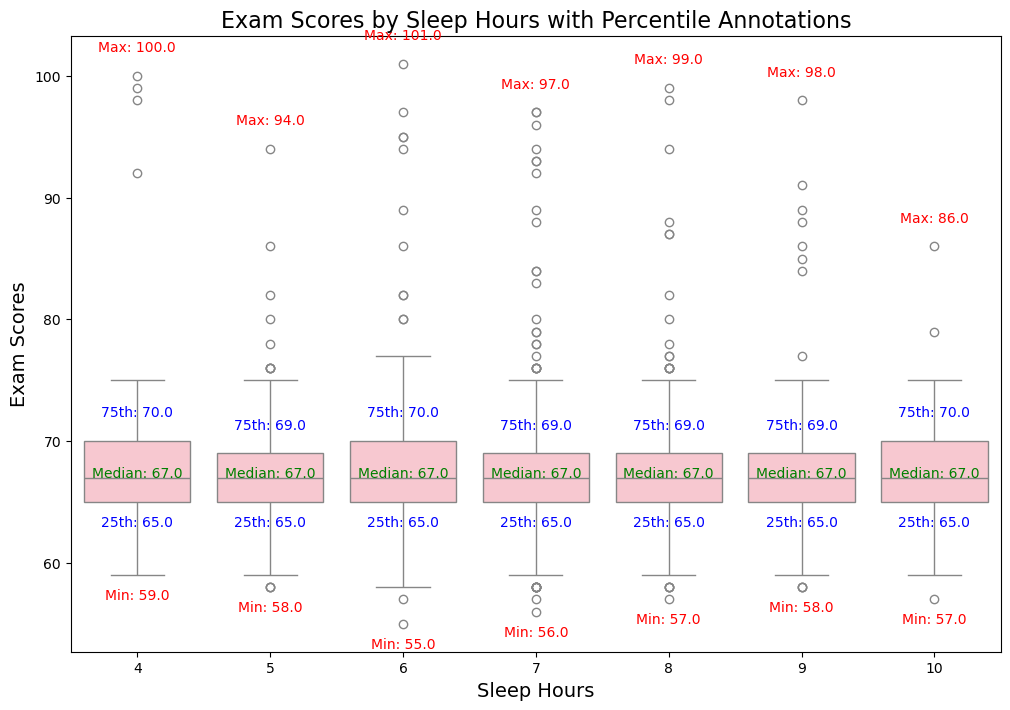

In [13]:
plt.figure(figsize=(12, 8))
ax = sns.boxplot(x='Sleep_Hours', y='Exam_Score', data=students, color='pink')

# Calculate statistics
stats = students.groupby('Sleep_Hours')['Exam_Score'].describe(percentiles=[0.25, 0.5, 0.75]).reset_index()

# Annotate min, max, 25th, 75th percentiles, and median
for i, row in stats.iterrows():
    ax.text(i, row['25%'] - 2, f"25th: {row['25%']:.1f}", ha='center', color='blue', fontsize=10)
    ax.text(i, row['50%'], f"Median: {row['50%']:.1f}", ha='center', color='green', fontsize=10)
    ax.text(i, row['75%'] + 2, f"75th: {row['75%']:.1f}", ha='center', color='blue', fontsize=10)
    ax.text(i, row['min'] - 2, f"Min: {row['min']:.1f}", ha='center', color='red', fontsize=10)
    ax.text(i, row['max'] + 2, f"Max: {row['max']:.1f}", ha='center', color='red', fontsize=10)

# Add labels and title
plt.title('Exam Scores by Sleep Hours with Percentile Annotations', fontsize=16)
plt.xlabel('Sleep Hours', fontsize=14)
plt.ylabel('Exam Scores', fontsize=14)

##### How does the number of sleep hours affect student performance?
##### General Observations:
- Consistency Across Groups:
The medians (67.0) are consistent across all sleep hour categories, indicating that the central tendency of Exam_Score is unaffected by Sleep_Hours.
- Range of Scores:
The interquartile ranges (IQR, 25th to 75th percentiles) are also nearly identical for all categories, suggesting that most students' scores cluster within a similar range, regardless of sleep hours.
- Outliers:
There are many outliers above the 75th percentile in most categories, suggesting that some students performed significantly better than the majority, irrespective of their sleep hours.
Outliers are less common for lower scores (below the 25th percentile).
- Min and Max Values:
The minimum scores decrease slightly as sleep hours increase (e.g., min of 59.0 for 4 hours, down to 55.0 for 6 hours). This might suggest that more sleep correlates with a slight reduction in very poor performance.
Maximum scores vary without a clear trend across sleep hours.

##### Key Insights:
Sleep hours alone might not strongly influence exam performance in this dataset, as the median and IQR remain stable across all categories.
Extreme performance (outliers) seems to occur regardless of sleep hours, indicating that other factors likely contribute to high or low scores.

#### Descriptive question 2: Is there a correlation between teacher quality and motivation?

In [14]:
# Answer the descriptive question 2 with statistical analyses and graphs 
# - Is there a correlation between teacher quality and motivation? 

# Check for lengths of 2 variables Teacher_Quality and Motivation_Level before making graphs
len(students['Teacher_Quality'])
len(students['Motivation_Level'])

6378

6378

Text(0.5, 0, 'Teacher Quality')

Text(0, 0.5, 'Motivation Level')

Text(0.5, 1.0, 'Scatter Plot of Teacher Quality vs Motivation Level')

([<matplotlib.axis.XTick at 0x132c6c370>,
 [Text(3, 0, 'High'), Text(2, 0, 'Medium'), Text(1, 0, 'Low')])

([<matplotlib.axis.YTick at 0x132c6d030>,
 [Text(0, 3, 'High'), Text(0, 2, 'Medium'), Text(0, 1, 'Low')])

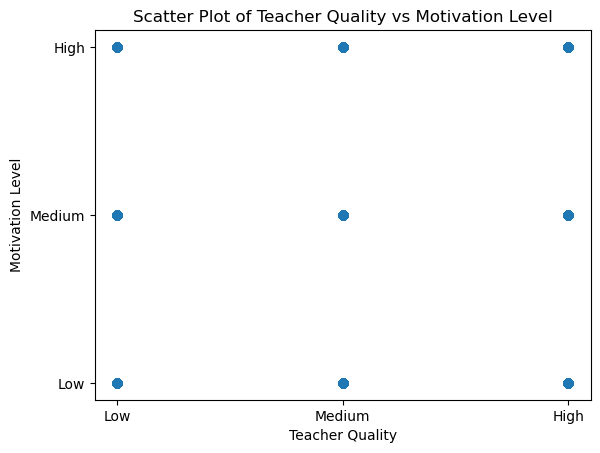

In [15]:
# Because Teacher_Quality and Motivation_Level are categorical variables, we need to map each value to a numeric value
teacher_quality_map = {'High': 3, 'Medium': 2, 'Low': 1}
motivation_level_map = {'High': 3, 'Medium': 2, 'Low': 1}

# Apply mappings to create numeric columns
students['Teacher_Quality_Num'] = students['Teacher_Quality'].map(teacher_quality_map)
students['Motivation_Level_Num'] = students['Motivation_Level'].map(motivation_level_map)

# Prepare the axes
x = students['Teacher_Quality_Num']
y = students['Motivation_Level_Num']

# Create the scatter plot
plt.scatter(x, y)
plt.xlabel('Teacher Quality')
plt.ylabel('Motivation Level')
plt.title('Scatter Plot of Teacher Quality vs Motivation Level')

# Show category labels on the axes instead of numeric values
plt.xticks(list(teacher_quality_map.values()), list(teacher_quality_map.keys()))
plt.yticks(list(motivation_level_map.values()), list(motivation_level_map.keys()))

In [16]:
np.corrcoef(x, y)

array([[ 1.        , -0.01283163],
       [-0.01283163,  1.        ]])

##### Is there a correlation between teacher quality and motivation?

By observing the graph, we can see that the points are distributed evenly (and overlapped). And by double-checking by method np.corrcoef(), the absolute value of the correlation is 0.01, and we can conclude that there is a very weak to no correlation between the two variables. This means that the teacher quality does not impact students' motivation level.

It is also important to notice that the dataset we are examining is synthetically generated for educational and analytical purposes, and is not sourced from real-world institutions, however, it is created to simulate realistic scenarios for analyzing student performance factors. So, I think we still can use it to practice the concepts and techniques we've learned in this course.

#### Descriptive question 3: What is the most common motivation level among students who scored above 70 on the exam? 

In [17]:
# Answer the descriptive question 3 with statistical analyses and graphs 
# - What is the most common motivation level among students who scored above 70 on the exam?

# Create a filter to filter the students who scored above 70 on the exam
high_scores_filters = students['Exam_Score'] > 70
high_scores_students = students[high_scores_filters]
high_scores_students.shape

(1055, 22)

In [18]:
motivation_counts = high_scores_students['Motivation_Level'].value_counts()

Text(0.5, 0, 'Motivation Level')

Text(0, 0.5, 'Count')

Text(0.5, 1.0, 'Motivation Level of Students Who Scored Above 70')

[Text(0, 0, '542'), Text(0, 0, '262'), Text(0, 0, '251')]

(array([0, 1, 2]),
 [Text(0, 0, 'Medium'), Text(1, 0, 'High'), Text(2, 0, 'Low')])

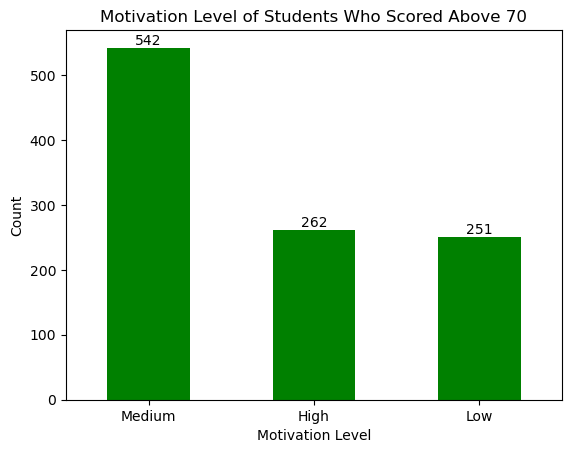

In [46]:
motivation_bar_plot = motivation_counts.plot(kind='bar', color='green')
plt.xlabel('Motivation Level')
plt.ylabel('Count')
plt.title('Motivation Level of Students Who Scored Above 70')
motivation_bar_plot.bar_label(motivation_bar_plot.containers[0], label_type='edge')
plt.xticks(rotation=0)

##### What is the most common motivation level among students who scored above 70 on the exam?

The bar chart gives us three key insights:

- Medium Motivation Can Still Result in High Performance: Students who scored above 70 most commonly had a motivation level of Medium, and furthermore achieved the maximum exam score at 101. Therefore, students with moderate motivation perform well, implying that a balance between academic stress and level-headedness is the key to optimal results.
- High Motivation May Decrease Performance: Though 262 students had a High motivation level, the number of observations relative to the Medium category is comparatively low, in addition to the High group seeing a lower overall range of exam scores.  This serves as an indication that high motivation on an exam does not necessarily beget high performance, and, in fact, could actively hinder students' performance instead.
- Low Motivation Doesn't Mean Low Performance: Despite being the smallest group, the students with Low motivation still had a very similar number of observations to those with high motivation, and in many cases performed equally well. One interpretation of this is that despite limited levels of motivation, other factors in the dataset, such as parental involvement or teacher quality, can also contribute and influence performance to the same extent. While Motivation can impact performance positively or negatively, it does so in tandem with other factors in the dataset.

Text(0.5, 1.0, 'Exam Scores by Motivation Level with Percentile Annotations')

Text(0.5, 0, 'Motivation Level')

Text(0, 0.5, 'Exam Scores')

([0, 1, 2], [Text(0, 0, 'Low'), Text(1, 0, 'Medium'), Text(2, 0, 'High')])

(array([ 50.,  60.,  70.,  80.,  90., 100., 110.]),
 [Text(0, 50.0, '50'),
  Text(0, 60.0, '60'),
  Text(0, 70.0, '70'),
  Text(0, 80.0, '80'),
  Text(0, 90.0, '90'),
  Text(0, 100.0, '100'),
  Text(0, 110.0, '110')])

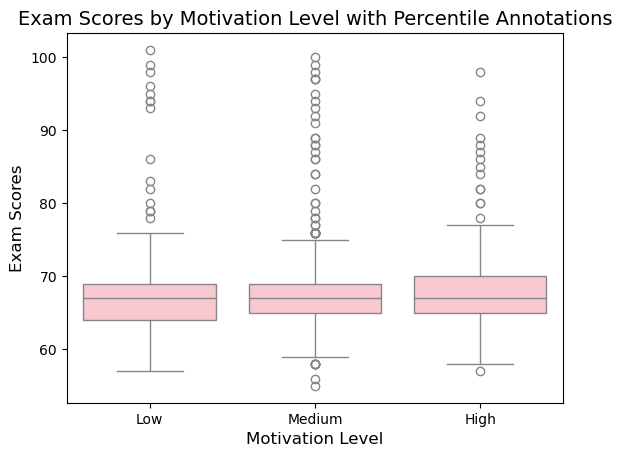

In [45]:
# Draw boxplot
ax = sns.boxplot(x='Motivation_Level', y='Exam_Score', data=students, color='pink')

# Add labels and title
plt.title('Exam Scores by Motivation Level with Percentile Annotations', fontsize=14)
plt.xlabel('Motivation Level', fontsize=12)
plt.ylabel('Exam Scores', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

The average exam score increased slightly with higher motivation levels, though the maximum score decreased.

#### Descriptive question 4: Are highly educated parents more involved in a child’s education?

In [21]:
# Answer the descriptive question 4 with statistical analyses and graphs 
# - Are highly educated parents more involved in a child’s education?

# Check for lengths of 2 variables Parental_Education_Level and Parental_Involvement before making graphs
len(students['Parental_Education_Level'])
len(students['Parental_Involvement'])

6378

6378

<Axes: xlabel='Parental_Education_Level', ylabel='count'>

Text(0.5, 1.0, 'Parental Involvement by Education Level')

Text(0.5, 0, 'Parental Education Level')

Text(0, 0.5, 'Number of Parents')

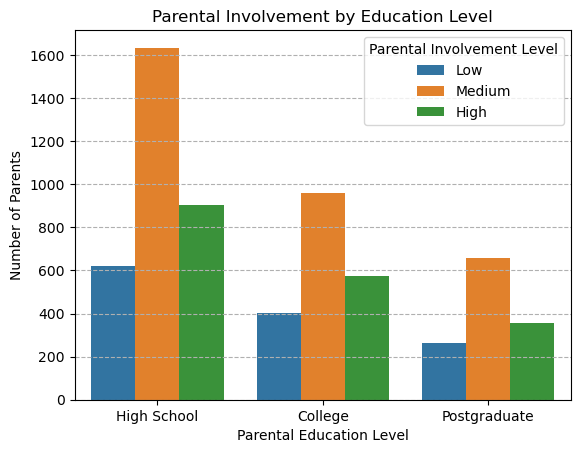

In [22]:
# Prepare key parameters of countplot
sns.countplot(
    data=students,
    x="Parental_Education_Level",
    hue="Parental_Involvement",
    order=["High School", "College", "Postgraduate"]
)
# Define countplot characteristics
plt.title("Parental Involvement by Education Level")
plt.xlabel("Parental Education Level")
plt.ylabel("Number of Parents")
plt.legend(title="Parental Involvement Level")
plt.grid(axis="y", linestyle="--")

##### Are highly educated parents more involved in a child's education?

The count plot gives us 4 key insights:

- Highly educated postgraduate parents are less involved in their children's education. 
- High School educated parents are more involved in their children's education than College or postgraduate-educated parents
- Overall, most parents across education levels have a Medium level of involvement in their children's education.
- Overall, parents are less likely to have a low level of involvement in their children's education

### Models and Analysis

#### Predictive Question: What factors most strongly predict whether a student will score above 75 on the exam?

In [23]:
students_transformed_scaled.info()
students_transformed_scaled.head()

<class 'pandas.core.frame.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Hours_Studied                          6378 non-null   float64
 1   Attendance                             6378 non-null   float64
 2   Sleep_Hours                            6378 non-null   float64
 3   Previous_Scores                        6378 non-null   float64
 4   Tutoring_Sessions                      6378 non-null   float64
 5   Physical_Activity                      6378 non-null   float64
 6   Exam_Score                             6378 non-null   float64
 7   Parental_Involvement_Low               6378 non-null   int64  
 8   Parental_Involvement_Medium            6378 non-null   int64  
 9   Access_to_Resources_Low                6378 non-null   int64  
 10  Access_to_Resources_Medium             6378 non-null   int64  
 11  Extracurr

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,Extracurricular_Activities_Yes,Motivation_Level_Low,Motivation_Level_Medium,Internet_Access_Yes,Family_Income_Low,Family_Income_Medium,Teacher_Quality_Low,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,0.505079,0.344520,-0.023819,-0.143491,-1.211858,0.026516,-0.064416,1,0,0,0,0,1,0,1,1,0,0,1,1,0,1,0,1,0,0,1,1
1,-0.163260,-1.387109,0.657418,-1.115763,0.409036,0.998480,-1.597410,1,0,0,1,0,1,0,1,0,1,0,1,1,0,0,0,0,0,1,0,0
2,0.672163,1.556661,-0.023819,1.106573,0.409036,0.998480,1.724077,0,1,0,1,1,0,1,1,0,1,0,1,1,1,0,0,0,1,0,1,1
3,1.507587,0.777428,0.657418,1.592709,-0.401411,0.998480,0.957580,1,0,0,1,1,0,1,1,0,1,0,1,1,0,0,0,1,0,1,0,1
4,-0.163260,1.037172,-0.705056,-0.699075,1.219483,0.998480,0.702081,0,1,0,1,1,0,1,1,0,1,0,0,1,1,0,0,0,0,0,1,0


In [24]:
# Create a target variable: 'Scored_Above_75'
# Target = 1 if Exam_Score > 75
# Target = 0 if Exam_Score <= 75

students_transformed_scaled['Scored_Above_75'] = students['Exam_Score'].apply(lambda x: 1 if x > 75 else 0)

In [25]:
# Prepare target
target = ['Scored_Above_75']

# Prepare the feature column list
features = students_transformed_scaled.columns.tolist()
features.remove('Exam_Score')
features.remove('Scored_Above_75')

In [26]:
# Define y (target) and X (features)
y = students_transformed_scaled[target]
X = students_transformed_scaled[features]

In [27]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

In [28]:
# Fit the model using logistic regression
from sklearn.linear_model import LogisticRegression
logRegressor = LogisticRegression(class_weight='balanced')
logRegressor.fit(X_train, y_train.values.ravel())

LogisticRegression(class_weight='balanced')

In [29]:
# Get the prediction
y_pred = logRegressor.predict(X_test)

In [30]:
# Evaluate the model
# Calculate the accuracy rate
from sklearn.metrics import accuracy_score
accuracy_score(y_true = y_test, y_pred = y_pred)

0.696437054631829

In [31]:
# To understand whether the model is biased toward one class, you should inspect the confusion matrix
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[1458,  623],
       [  16,    8]])

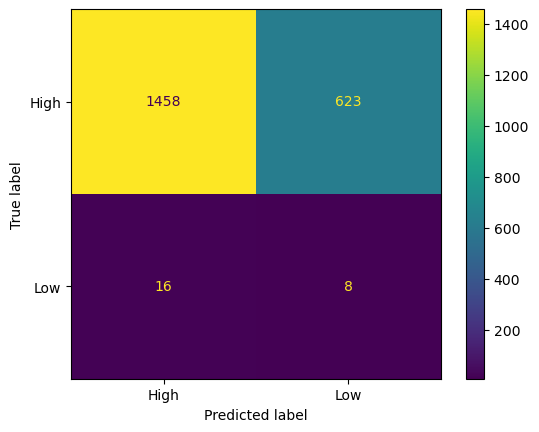

In [32]:
# Plot the Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['High', 'Low'])
disp.plot()

In [33]:
# Extract feature coefficients
feature_importance = logRegressor.coef_[0]  # Since Logistic Regression is binary, coef_ will have a single row
feature_names = X_train.columns

# Map feature names to their corresponding coefficients
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': feature_importance
})

# Sort the features by the absolute value of their coefficients to find the most important ones
feature_df['Abs_Coefficient'] = feature_df['Coefficient'].abs()
feature_df = feature_df.sort_values(by='Abs_Coefficient', ascending=False)

feature_df

,Feature,Coefficient,Abs_Coefficient
8,Access_to_Resources_Low,-0.949563,0.949563
14,Family_Income_Low,-0.891170,0.891170
11,Motivation_Level_Low,-0.731929,0.731929
12,Motivation_Level_Medium,-0.718573,0.718573
15,Family_Income_Medium,-0.642236,0.642236
7,Parental_Involvement_Medium,-0.570570,0.570570
9,Access_to_Resources_Medium,-0.567977,0.567977
16,Teacher_Quality_Low,-0.552511,0.552511
6,Parental_Involvement_Low,-0.399364,0.399364
5,Physical_Activity,-0.390163,0.390163


<Figure size 1000x800 with 0 Axes>

<BarContainer object of 16 artists>

Text(0.5, 0, 'Coefficient Value')

Text(0, 0.5, 'Features')

Text(0.5, 1.0, 'Top 16 Features Predicting Scored Above 75')

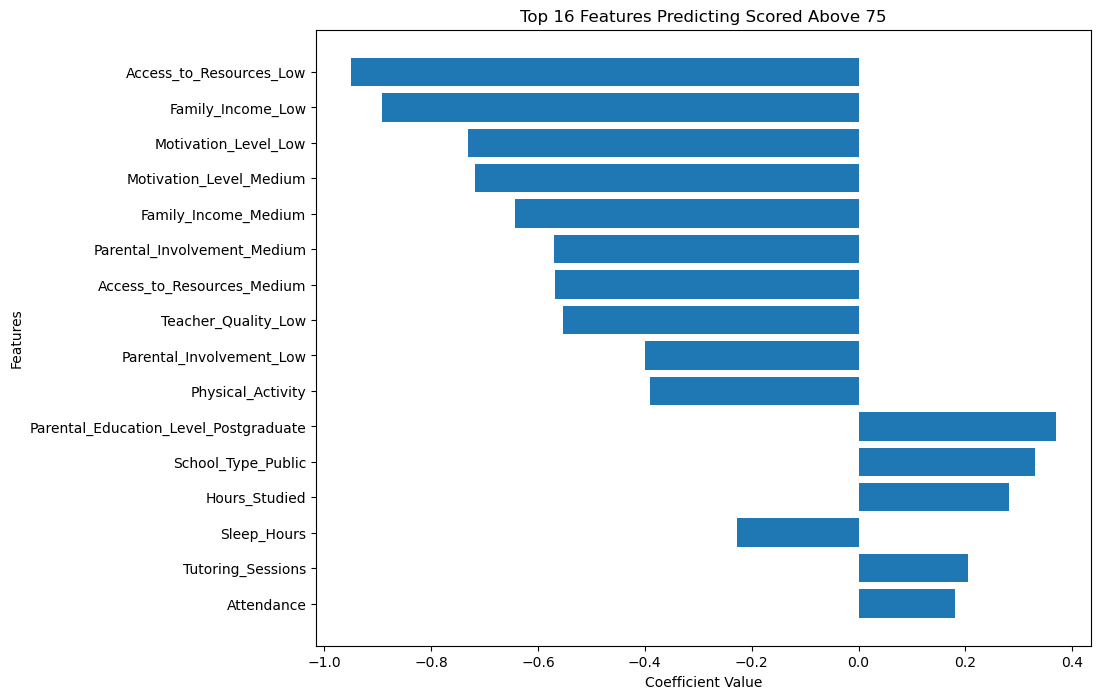

In [34]:
# Visualize the top N features (e.g., top 10)
top_n = 16
plt.figure(figsize=(10, 8))
plt.barh(feature_df['Feature'][:top_n], feature_df['Coefficient'][:top_n])
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.title(f'Top {top_n} Features Predicting Scored Above 75')
plt.gca().invert_yaxis()